In [93]:
#import libraries
import numpy as np
import pandas as pd

In [94]:
#Import the dataset
df = pd.read_csv('/content/creditcard.csv')
df

<ipython-input-94-b6ae070e2421>:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/creditcard.csv')


,NPA Status,Revolving Utilization Of Unsecured Lines,age,Gender,Region,Monthly Income,Rented_Own House,Occupation,Education,Number Of Time 30-59 Days Past Due Not Worse,Debt Ratio,Monthly Income.1,Number Of Open Credit Lines And Loans,Number Of Times 90 Days Late,Number Real Estate Loans Or Lines,Number Of Time 60-89Days Past Due Not Worse,Number Of Dependents,Good_Bad
0,1.0,0.766127,45.0,Male,South,9120.0,Ownhouse,Self_Emp,Matric,2.0,0.802982,9120.0,13.0,0.0,6.0,0.0,2.0,Bad
1,0.0,0.957151,40.0,Female,South,2600.0,Ownhouse,Self_Emp,Graduate,0.0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.0,Good
2,0.0,0.658180,38.0,Female,South,3042.0,Ownhouse,Self_Emp,PhD,1.0,0.085113,3042.0,2.0,1.0,0.0,0.0,0.0,Good
3,0.0,0.233810,30.0,Female,South,3300.0,Ownhouse,Self_Emp,Professional,0.0,0.036050,3300.0,5.0,0.0,0.0,0.0,0.0,Good
4,0.0,0.907239,49.0,Male,South,63588.0,Ownhouse,Self_Emp,Post-Grad,1.0,0.024926,63588.0,7.0,0.0,1.0,0.0,0.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149997,0.0,0.246044,58.0,Male,North,NaN,Rented,Officer2,Professional,0.0,3870.000000,NaN,18.0,0.0,1.0,0.0,0,Good
149998,0.0,0.000000,30.0,Male,North,5716.0,Rented,Non-officer,Professional,0.0,0.000000,5716.0,4.0,0.0,0.0,0.0,0,Good
149999,0.0,0.850283,64.0,Male,North,8158.0,Ownhouse,Self_Emp,Professional,0.0,0.249908,8158.0,8.0,0.0,2.0,0.0,0,Good
150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Good,NaN


In [95]:
#shape of the data
df.shape

(150002, 18)

#FINDING MISSING OR NULL VALUES


In [96]:
# information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150002 entries, 0 to 150001
Data columns (total 18 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   NPA Status                                    150000 non-null  float64
 1   Revolving Utilization Of Unsecured Lines      150000 non-null  float64
 2   age                                           150000 non-null  float64
 3   Gender                                        150000 non-null  object 
 4   Region                                        150000 non-null  object 
 5   Monthly Income                                120269 non-null  float64
 6   Rented_Own House                              150000 non-null  object 
 7   Occupation                                    150000 non-null  object 
 8   Education                                     150000 non-null  object 
 9   Number Of Time 30-59 Days Past Due Not Worse  15

In [97]:
#to know the null values are present in the data or not
df.isnull()

,NPA Status,Revolving Utilization Of Unsecured Lines,age,Gender,Region,Monthly Income,Rented_Own House,Occupation,Education,Number Of Time 30-59 Days Past Due Not Worse,Debt Ratio,Monthly Income.1,Number Of Open Credit Lines And Loans,Number Of Times 90 Days Late,Number Real Estate Loans Or Lines,Number Of Time 60-89Days Past Due Not Worse,Number Of Dependents,Good_Bad
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149997,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False
149998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
149999,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
150000,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True


In [98]:
#to know the count of null values in each column
df.isnull().sum()

,0
NPA Status,2
Revolving Utilization Of Unsecured Lines,2
age,2
Gender,2
Region,2
Monthly Income,29733
Rented_Own House,2
Occupation,2
Education,2
Number Of Time 30-59 Days Past Due Not Worse,2


In [99]:
#total count of null values
df.isnull().sum().sum()

63420

#HANDLE THE MISSING VALUES

In [100]:
#fill the missing values in numerical_coloumns with aproximate number using KNN
from sklearn.impute import KNNImputer
impute=KNNImputer()
for i in df.select_dtypes(include='number').columns:
  df[i]=impute.fit_transform(df[[i]])

In [101]:
#check the null values after the treatment of numerical coloums
df.isnull().sum()

,0
NPA Status,0
Revolving Utilization Of Unsecured Lines,0
age,0
Gender,2
Region,2
Monthly Income,0
Rented_Own House,2
Occupation,2
Education,2
Number Of Time 30-59 Days Past Due Not Worse,0


In [102]:
#handle the remaining text columns with fillna(ffill) -> forward_fill

df['Good_Bad'] = df['Good_Bad'].ffill()
df['Rented_Own House'] = df['Rented_Own House'].ffill()
df['Occupation'] = df['Occupation'].ffill()

df.isnull().sum()


,0
NPA Status,0
Revolving Utilization Of Unsecured Lines,0
age,0
Gender,2
Region,2
Monthly Income,0
Rented_Own House,0
Occupation,0
Education,2
Number Of Time 30-59 Days Past Due Not Worse,0


In [103]:
#handle the remaining text columns with fillna(ffill) -> forward_fill
df['Gender'] = df['Gender'].ffill()
df['Education'] = df['Education'].ffill()
df.isnull().sum()

,0
NPA Status,0
Revolving Utilization Of Unsecured Lines,0
age,0
Gender,0
Region,2
Monthly Income,0
Rented_Own House,0
Occupation,0
Education,0
Number Of Time 30-59 Days Past Due Not Worse,0


In [104]:
#handle the reaminig to coloums using fillna(mode)method

df['Number Of Dependents'] = df['Number Of Dependents'].fillna(df['Number Of Dependents'].mode()[0])
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])
df.isnull().sum()

,0
NPA Status,0
Revolving Utilization Of Unsecured Lines,0
age,0
Gender,0
Region,0
Monthly Income,0
Rented_Own House,0
Occupation,0
Education,0
Number Of Time 30-59 Days Past Due Not Worse,0


In [105]:
#after cleaning the data once check the data
df

,NPA Status,Revolving Utilization Of Unsecured Lines,age,Gender,Region,Monthly Income,Rented_Own House,Occupation,Education,Number Of Time 30-59 Days Past Due Not Worse,Debt Ratio,Monthly Income.1,Number Of Open Credit Lines And Loans,Number Of Times 90 Days Late,Number Real Estate Loans Or Lines,Number Of Time 60-89Days Past Due Not Worse,Number Of Dependents,Good_Bad
0,1.00000,0.766127,45.000000,Male,South,9120.000000,Ownhouse,Self_Emp,Matric,2.000000,0.802982,9120.000000,13.00000,0.000000,6.00000,0.000000,2.0,Bad
1,0.00000,0.957151,40.000000,Female,South,2600.000000,Ownhouse,Self_Emp,Graduate,0.000000,0.121876,2600.000000,4.00000,0.000000,0.00000,0.000000,1.0,Good
2,0.00000,0.658180,38.000000,Female,South,3042.000000,Ownhouse,Self_Emp,PhD,1.000000,0.085113,3042.000000,2.00000,1.000000,0.00000,0.000000,0.0,Good
3,0.00000,0.233810,30.000000,Female,South,3300.000000,Ownhouse,Self_Emp,Professional,0.000000,0.036050,3300.000000,5.00000,0.000000,0.00000,0.000000,0.0,Good
4,0.00000,0.907239,49.000000,Male,South,63588.000000,Ownhouse,Self_Emp,Post-Grad,1.000000,0.024926,63588.000000,7.00000,0.000000,1.00000,0.000000,0.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149997,0.00000,0.246044,58.000000,Male,North,6670.221237,Rented,Officer2,Professional,0.000000,3870.000000,6670.221237,18.00000,0.000000,1.00000,0.000000,0,Good
149998,0.00000,0.000000,30.000000,Male,North,5716.000000,Rented,Non-officer,Professional,0.000000,0.000000,5716.000000,4.00000,0.000000,0.00000,0.000000,0,Good
149999,0.00000,0.850283,64.000000,Male,North,8158.000000,Ownhouse,Self_Emp,Professional,0.000000,0.249908,8158.000000,8.00000,0.000000,2.00000,0.000000,0,Good
150000,0.06684,6.048438,52.295207,Male,Central,6670.221237,Ownhouse,Self_Emp,Professional,0.421033,353.005076,6670.221237,8.45276,0.265973,1.01824,0.240387,Good,Good


In [106]:
#to remove repeated column in data(dropna)

df1 = df.drop(['Monthly Income.1'],axis=1)
df1

,NPA Status,Revolving Utilization Of Unsecured Lines,age,Gender,Region,Monthly Income,Rented_Own House,Occupation,Education,Number Of Time 30-59 Days Past Due Not Worse,Debt Ratio,Number Of Open Credit Lines And Loans,Number Of Times 90 Days Late,Number Real Estate Loans Or Lines,Number Of Time 60-89Days Past Due Not Worse,Number Of Dependents,Good_Bad
0,1.00000,0.766127,45.000000,Male,South,9120.000000,Ownhouse,Self_Emp,Matric,2.000000,0.802982,13.00000,0.000000,6.00000,0.000000,2.0,Bad
1,0.00000,0.957151,40.000000,Female,South,2600.000000,Ownhouse,Self_Emp,Graduate,0.000000,0.121876,4.00000,0.000000,0.00000,0.000000,1.0,Good
2,0.00000,0.658180,38.000000,Female,South,3042.000000,Ownhouse,Self_Emp,PhD,1.000000,0.085113,2.00000,1.000000,0.00000,0.000000,0.0,Good
3,0.00000,0.233810,30.000000,Female,South,3300.000000,Ownhouse,Self_Emp,Professional,0.000000,0.036050,5.00000,0.000000,0.00000,0.000000,0.0,Good
4,0.00000,0.907239,49.000000,Male,South,63588.000000,Ownhouse,Self_Emp,Post-Grad,1.000000,0.024926,7.00000,0.000000,1.00000,0.000000,0.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149997,0.00000,0.246044,58.000000,Male,North,6670.221237,Rented,Officer2,Professional,0.000000,3870.000000,18.00000,0.000000,1.00000,0.000000,0,Good
149998,0.00000,0.000000,30.000000,Male,North,5716.000000,Rented,Non-officer,Professional,0.000000,0.000000,4.00000,0.000000,0.00000,0.000000,0,Good
149999,0.00000,0.850283,64.000000,Male,North,8158.000000,Ownhouse,Self_Emp,Professional,0.000000,0.249908,8.00000,0.000000,2.00000,0.000000,0,Good
150000,0.06684,6.048438,52.295207,Male,Central,6670.221237,Ownhouse,Self_Emp,Professional,0.421033,353.005076,8.45276,0.265973,1.01824,0.240387,Good,Good


In [107]:
#to know the any duplicates are present in data
df1.duplicated().sum()

25

In [108]:
#to remove the duolicate values (dropna)
df2 = df1.drop_duplicates()
df2

,NPA Status,Revolving Utilization Of Unsecured Lines,age,Gender,Region,Monthly Income,Rented_Own House,Occupation,Education,Number Of Time 30-59 Days Past Due Not Worse,Debt Ratio,Number Of Open Credit Lines And Loans,Number Of Times 90 Days Late,Number Real Estate Loans Or Lines,Number Of Time 60-89Days Past Due Not Worse,Number Of Dependents,Good_Bad
0,1.00000,0.766127,45.000000,Male,South,9120.000000,Ownhouse,Self_Emp,Matric,2.000000,0.802982,13.00000,0.000000,6.00000,0.000000,2.0,Bad
1,0.00000,0.957151,40.000000,Female,South,2600.000000,Ownhouse,Self_Emp,Graduate,0.000000,0.121876,4.00000,0.000000,0.00000,0.000000,1.0,Good
2,0.00000,0.658180,38.000000,Female,South,3042.000000,Ownhouse,Self_Emp,PhD,1.000000,0.085113,2.00000,1.000000,0.00000,0.000000,0.0,Good
3,0.00000,0.233810,30.000000,Female,South,3300.000000,Ownhouse,Self_Emp,Professional,0.000000,0.036050,5.00000,0.000000,0.00000,0.000000,0.0,Good
4,0.00000,0.907239,49.000000,Male,South,63588.000000,Ownhouse,Self_Emp,Post-Grad,1.000000,0.024926,7.00000,0.000000,1.00000,0.000000,0.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149997,0.00000,0.246044,58.000000,Male,North,6670.221237,Rented,Officer2,Professional,0.000000,3870.000000,18.00000,0.000000,1.00000,0.000000,0,Good
149998,0.00000,0.000000,30.000000,Male,North,5716.000000,Rented,Non-officer,Professional,0.000000,0.000000,4.00000,0.000000,0.00000,0.000000,0,Good
149999,0.00000,0.850283,64.000000,Male,North,8158.000000,Ownhouse,Self_Emp,Professional,0.000000,0.249908,8.00000,0.000000,2.00000,0.000000,0,Good
150000,0.06684,6.048438,52.295207,Male,Central,6670.221237,Ownhouse,Self_Emp,Professional,0.421033,353.005076,8.45276,0.265973,1.01824,0.240387,Good,Good


In [109]:
#after data handling shape
df2.shape

(149977, 17)

In [110]:
#cross check the null values
df2.isnull().sum()


,0
NPA Status,0
Revolving Utilization Of Unsecured Lines,0
age,0
Gender,0
Region,0
Monthly Income,0
Rented_Own House,0
Occupation,0
Education,0
Number Of Time 30-59 Days Past Due Not Worse,0


In [111]:
#data after cleaning
df2


,NPA Status,Revolving Utilization Of Unsecured Lines,age,Gender,Region,Monthly Income,Rented_Own House,Occupation,Education,Number Of Time 30-59 Days Past Due Not Worse,Debt Ratio,Number Of Open Credit Lines And Loans,Number Of Times 90 Days Late,Number Real Estate Loans Or Lines,Number Of Time 60-89Days Past Due Not Worse,Number Of Dependents,Good_Bad
0,1.00000,0.766127,45.000000,Male,South,9120.000000,Ownhouse,Self_Emp,Matric,2.000000,0.802982,13.00000,0.000000,6.00000,0.000000,2.0,Bad
1,0.00000,0.957151,40.000000,Female,South,2600.000000,Ownhouse,Self_Emp,Graduate,0.000000,0.121876,4.00000,0.000000,0.00000,0.000000,1.0,Good
2,0.00000,0.658180,38.000000,Female,South,3042.000000,Ownhouse,Self_Emp,PhD,1.000000,0.085113,2.00000,1.000000,0.00000,0.000000,0.0,Good
3,0.00000,0.233810,30.000000,Female,South,3300.000000,Ownhouse,Self_Emp,Professional,0.000000,0.036050,5.00000,0.000000,0.00000,0.000000,0.0,Good
4,0.00000,0.907239,49.000000,Male,South,63588.000000,Ownhouse,Self_Emp,Post-Grad,1.000000,0.024926,7.00000,0.000000,1.00000,0.000000,0.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149997,0.00000,0.246044,58.000000,Male,North,6670.221237,Rented,Officer2,Professional,0.000000,3870.000000,18.00000,0.000000,1.00000,0.000000,0,Good
149998,0.00000,0.000000,30.000000,Male,North,5716.000000,Rented,Non-officer,Professional,0.000000,0.000000,4.00000,0.000000,0.00000,0.000000,0,Good
149999,0.00000,0.850283,64.000000,Male,North,8158.000000,Ownhouse,Self_Emp,Professional,0.000000,0.249908,8.00000,0.000000,2.00000,0.000000,0,Good
150000,0.06684,6.048438,52.295207,Male,Central,6670.221237,Ownhouse,Self_Emp,Professional,0.421033,353.005076,8.45276,0.265973,1.01824,0.240387,Good,Good


#FINDING OUTLIERS IN DATA

In [112]:
#import required libraries
import seaborn as sns
import matplotlib.pyplot as plt

In [113]:
#to see coloumns in data
df2.columns

Index(['NPA Status', 'Revolving Utilization Of Unsecured Lines', 'age',
       'Gender', 'Region', 'Monthly Income', 'Rented_Own House', 'Occupation',
       'Education', 'Number Of Time 30-59 Days Past Due Not Worse',
       'Debt Ratio', 'Number Of Open Credit Lines And Loans',
       'Number Of Times 90 Days Late', 'Number Real Estate Loans Or Lines',
       'Number Of Time 60-89Days Past Due Not Worse', 'Number Of Dependents',
       'Good_Bad'],
      dtype='object')

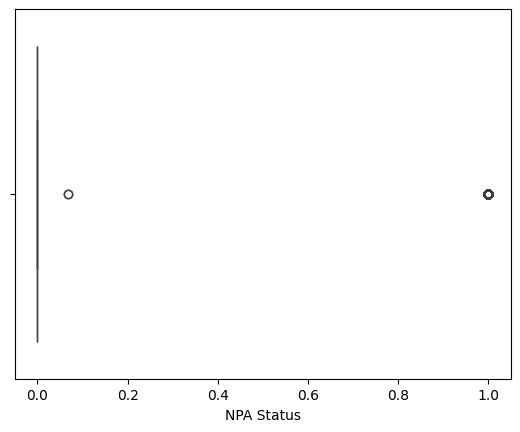

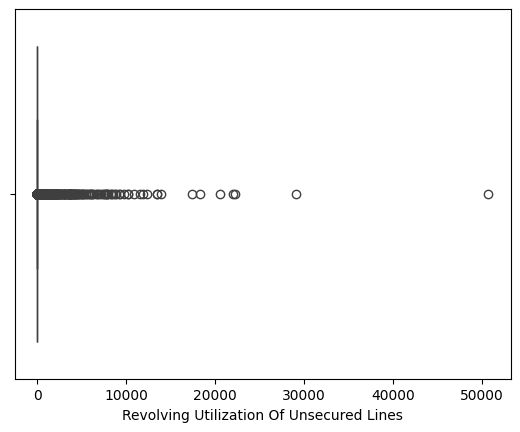

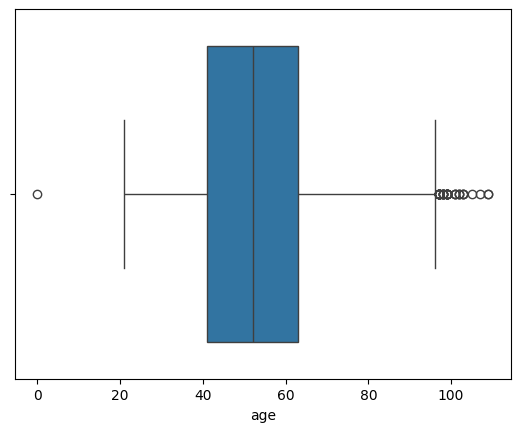

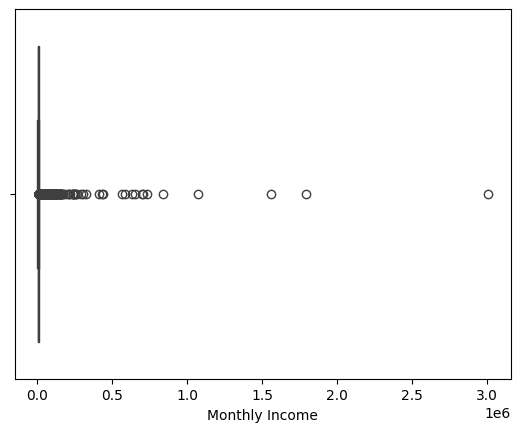

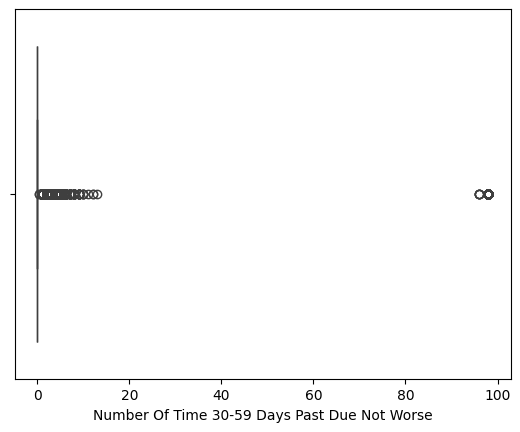

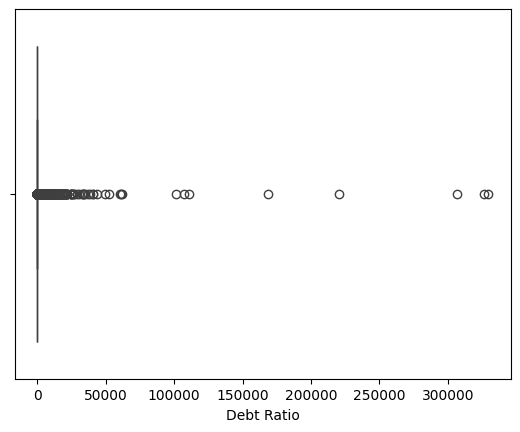

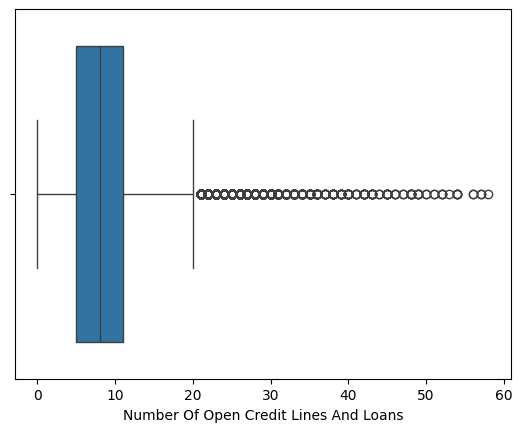

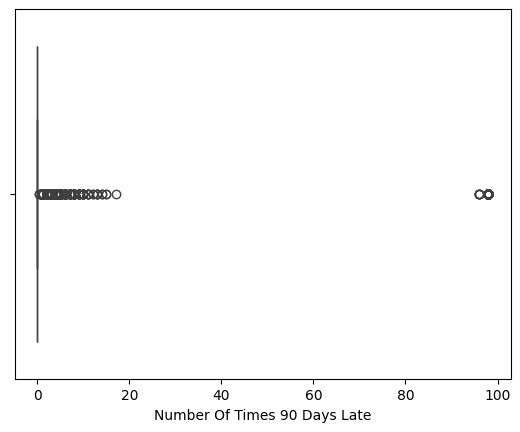

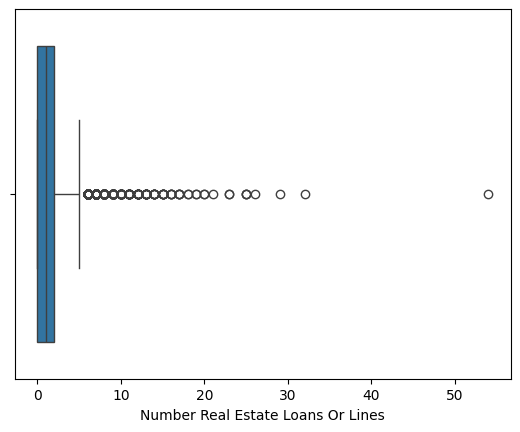

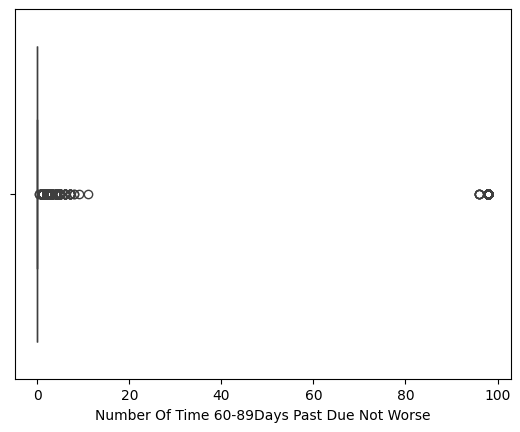

In [114]:
#to see outliers using boxplot
import warnings
warnings.filterwarnings("ignore")
for i in df2.select_dtypes(include="number").columns:
  sns.boxplot(data=df,x=i)
  plt.show()

#HANDLE THE OUTLIERS USING KNN

In [115]:
#detecting outliers in a box plot gives
#whisker gives lower and upper values for a given numerical column

def whisker(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lw = q1 - 1.5 * iqr
    uw = q3 + 1.5 * iqr
    return lw, uw


In [120]:
df2.columns

Index(['NPA Status', 'Revolving Utilization Of Unsecured Lines', 'age',
       'Gender', 'Region', 'Monthly Income', 'Rented_Own House', 'Occupation',
       'Education', 'Number Of Time 30-59 Days Past Due Not Worse',
       'Debt Ratio', 'Number Of Open Credit Lines And Loans',
       'Number Of Times 90 Days Late', 'Number Real Estate Loans Or Lines',
       'Number Of Time 60-89Days Past Due Not Worse', 'Number Of Dependents',
       'Good_Bad'],
      dtype='object')

In [121]:
#whisker values for example
whisker(df2['NPA Status'])

(0.0, 0.0)

In [122]:
whisker(df2['Revolving Utilization Of Unsecured Lines'])

(-0.763770612, 1.352627804)

In [128]:
#to handle outliers for numerical column
for i in ['NPA Status','Revolving Utilization Of Unsecured Lines','Monthly Income','Number Of Time 30-59 Days Past Due Not Worse',
          'Debt Ratio','Number Of Open Credit Lines And Loans','Number Of Times 90 Days Late','Number Real Estate Loans Or Lines',
          'Number Of Time 60-89Days Past Due Not Worse']:
       lw, uw = whisker(df2[i])
       df2[i] = np.where(df2[i] < lw, lw, df2[i])
       df2[i] = np.where(df2[i] > uw, uw, df2[i])

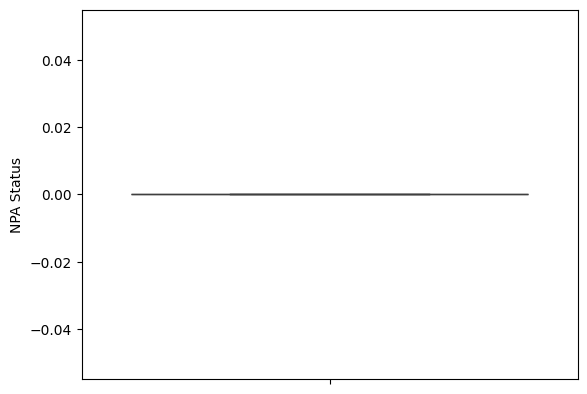

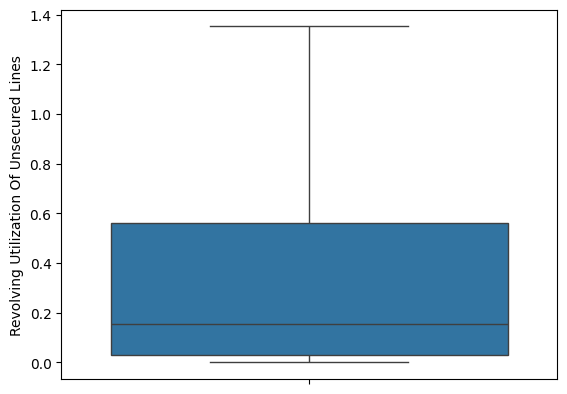

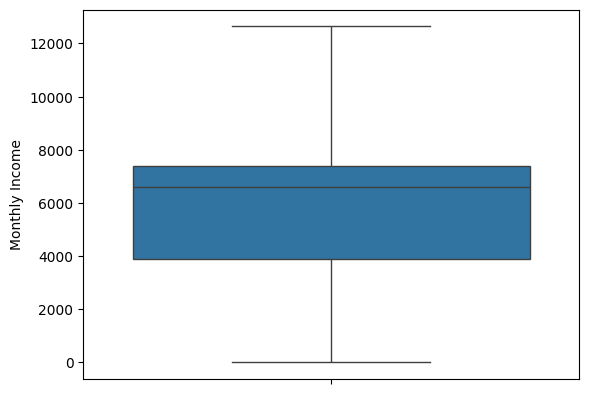

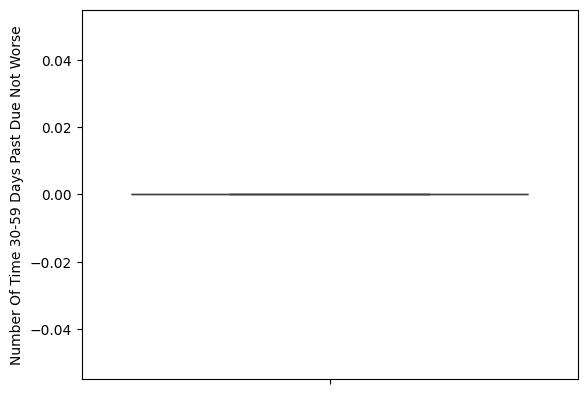

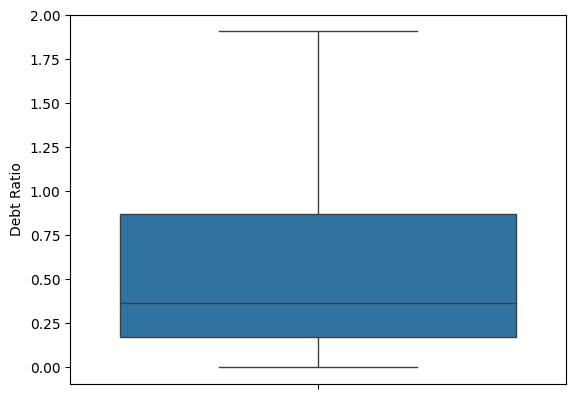

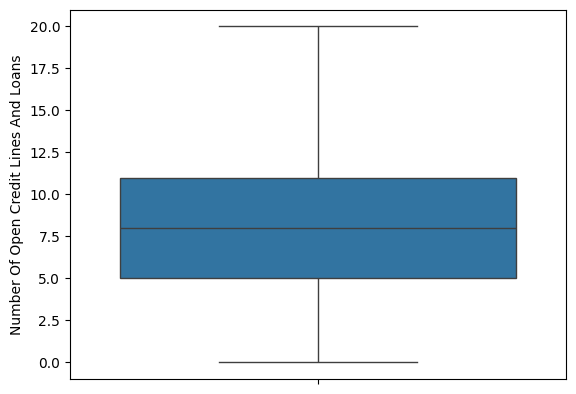

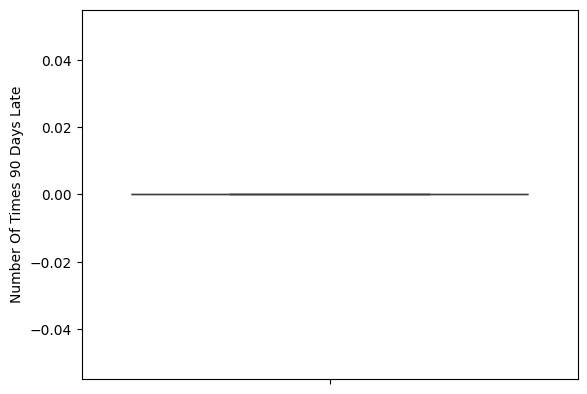

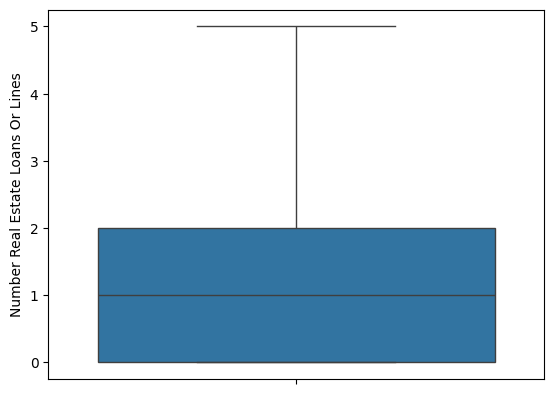

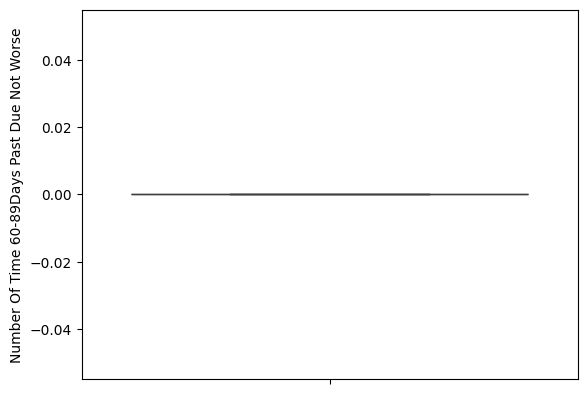

In [135]:
#after handle the outliers to showing the boxplot
for i in ['NPA Status','Revolving Utilization Of Unsecured Lines','Monthly Income','Number Of Time 30-59 Days Past Due Not Worse',
          'Debt Ratio','Number Of Open Credit Lines And Loans','Number Of Times 90 Days Late','Number Real Estate Loans Or Lines',
          'Number Of Time 60-89Days Past Due Not Worse']:
  sns.boxplot(df2[i])
  plt.show()

#CONVERT THE HANDLE DATA INTO CSV_FILE

In [138]:
df2.to_csv('credit_card.csv')


In [139]:
df2.shape

(149977, 17)

In [140]:
cf=pd.read_csv('/content/credit_card.csv')

In [141]:
cf.shape

(149977, 18)

In [142]:
#converted data
cf

,Unnamed: 0,NPA Status,Revolving Utilization Of Unsecured Lines,age,Gender,Region,Monthly Income,Rented_Own House,Occupation,Education,Number Of Time 30-59 Days Past Due Not Worse,Debt Ratio,Number Of Open Credit Lines And Loans,Number Of Times 90 Days Late,Number Real Estate Loans Or Lines,Number Of Time 60-89Days Past Due Not Worse,Number Of Dependents,Good_Bad
0,0,0.0,0.766127,45.000000,Male,South,9120.000000,Ownhouse,Self_Emp,Matric,0.0,0.802982,13.00000,0.0,5.00000,0.0,2.0,Bad
1,1,0.0,0.957151,40.000000,Female,South,2600.000000,Ownhouse,Self_Emp,Graduate,0.0,0.121876,4.00000,0.0,0.00000,0.0,1.0,Good
2,2,0.0,0.658180,38.000000,Female,South,3042.000000,Ownhouse,Self_Emp,PhD,0.0,0.085113,2.00000,0.0,0.00000,0.0,0.0,Good
3,3,0.0,0.233810,30.000000,Female,South,3300.000000,Ownhouse,Self_Emp,Professional,0.0,0.036050,5.00000,0.0,0.00000,0.0,0.0,Good
4,4,0.0,0.907239,49.000000,Male,South,12645.500000,Ownhouse,Self_Emp,Post-Grad,0.0,0.024926,7.00000,0.0,1.00000,0.0,0.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149972,149997,0.0,0.246044,58.000000,Male,North,6670.221237,Rented,Officer2,Professional,0.0,1.908871,18.00000,0.0,1.00000,0.0,0,Good
149973,149998,0.0,0.000000,30.000000,Male,North,5716.000000,Rented,Non-officer,Professional,0.0,0.000000,4.00000,0.0,0.00000,0.0,0,Good
149974,149999,0.0,0.850283,64.000000,Male,North,8158.000000,Ownhouse,Self_Emp,Professional,0.0,0.249908,8.00000,0.0,2.00000,0.0,0,Good
149975,150000,0.0,1.352628,52.295207,Male,Central,6670.221237,Ownhouse,Self_Emp,Professional,0.0,1.908871,8.45276,0.0,1.01824,0.0,Good,Good


In [143]:
cf.isnull().sum()

,0
Unnamed: 0,0
NPA Status,0
Revolving Utilization Of Unsecured Lines,0
age,0
Gender,0
Region,0
Monthly Income,0
Rented_Own House,0
Occupation,0
Education,0
